# 🛡️ SRDC: Semantics-Based Ransomware Detection and Classification
## LLM-Assisted Pre-Training (LATAP) → SRDC-GPT → Ransomware Family Classification + Zero-Day Detection

### Pipeline Overview:
1. **Mount Google Drive** & load data
2. **Data Loading & Exploration** – train_data.json
3. **Semantic Feature Processing** – CamelCase splitting, suffix removal, natural language conversion
4. **LATAP Pre-Training** – Fine-tune GPT-2 on cybersecurity domain corpus
5. **Multi-Feature Tokenization** – API, FILE, REG, DIR features separately
6. **SRDC-GPT Embedding Extraction** – Last-token embeddings
7. **Feature Compression** – AvgPooling / MaxPooling
8. **Ransomware Family Classifier** – Linear head on compressed features
9. **Zero-Day Detection** – Train on seen families, test on unseen
10. **Evaluation** – Accuracy, Recall, F1-Score, Confusion Matrix

---
## ⚙️ Step 0: Install Dependencies

In [1]:
!pip install transformers datasets accelerate scikit-learn seaborn matplotlib -q

---
## 📁 Step 1: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ─── Path Configuration ───────────────────────────────────────────────────────
# NOTE: Upload the following files to Google Drive under MyDrive/RTRP/data/:
#   • train_data (1).json   → rename to train_data.json
#   • corpus.txt            → pre-generated or auto-built in Step 2

DATA_DIR         = "/content/drive/MyDrive/RTRP/data/"
TRAIN_JSON_PATH  = DATA_DIR + "train_data.json"
CORPUS_PATH      = DATA_DIR + "corpus.txt"
LATAP_MODEL_DIR  = DATA_DIR + "latap_model/"
CLASSIFIER_PATH  = DATA_DIR + "srdc_classifier.pt"

print("✅ Drive mounted and paths configured.")

Mounted at /content/drive
✅ Drive mounted and paths configured.


---
## 📊 Step 2: Load & Explore Dataset

In [3]:
import pandas as pd, numpy as np, shutil, os

# Copy to local for reliable reading
src_candidates = [
    '/content/drive/MyDrive/RTRP/data/RansomwareData (1).csv',
    '/content/drive/MyDrive/RTRP/RansomwareData (1).csv',
]
dst = '/content/ransomwaredata.csv'

src = next((p for p in src_candidates if os.path.exists(p)), None)
if src is None:
    raise FileNotFoundError(
        'RansomwareData (1).csv not found in expected Drive locations. '
        'Upload it under MyDrive/RTRP/data/ or MyDrive/RTRP/.'
    )

if not os.path.exists(dst):
    shutil.copy(src, dst)

df_raw = pd.read_csv(dst, header=None)
print('Shape:', df_raw.shape)

# Column structure: 0=ID, 1=flag, 2=family_label/id, 3+=binary features
X_bin = df_raw.iloc[:, 3:].values.astype(np.float32)
raw_labels = df_raw[2].astype(str).str.strip()
print('Features:', X_bin.shape, '| Raw labels sample:', raw_labels.head().tolist())


Shape: (1524, 30970)
Features: (1524, 30967) | Raw labels sample: ['2', '3', '2', '5', '7']


In [4]:
from sklearn.preprocessing import LabelEncoder

ID_TO_FAMILY = {
    0: 'Goodware',   1: 'Critroni',    2: 'CryptLocker',
    3: 'CryptoWall', 4: 'KOLLAH',      5: 'Kovter',
    6: 'Locker',     7: 'MATSNU',      8: 'PGPCODER',
    9: 'Reveton',   10: 'TeslaCrypt', 11: 'Trojan-Ransom'
}

valid_numeric_ids = {str(k) for k in ID_TO_FAMILY}
if set(raw_labels.unique()).issubset(valid_numeric_ids):
    y_raw = raw_labels.map(lambda s: ID_TO_FAMILY[int(s)]).values
    print('Detected numeric family IDs in column 2 -> mapped to family names.')
else:
    y_raw = raw_labels.values
    print('Detected family names directly in column 2.')

le = LabelEncoder()
y = le.fit_transform(y_raw)
FAMILY_NAMES = list(le.classes_)
NUM_CLASSES = len(FAMILY_NAMES)

print(f'Classes ({NUM_CLASSES}): {FAMILY_NAMES}')
print('Distribution:')
for cls, cnt in zip(*np.unique(y_raw, return_counts=True)):
    print(f'  {cls:<15}: {cnt}')


Detected numeric family IDs in column 2 -> mapped to family names.
Classes (12): ['Critroni', 'CryptLocker', 'CryptoWall', 'Goodware', 'KOLLAH', 'Kovter', 'Locker', 'MATSNU', 'PGPCODER', 'Reveton', 'TeslaCrypt', 'Trojan-Ransom']
Distribution:
  Critroni       : 50
  CryptLocker    : 107
  CryptoWall     : 46
  Goodware       : 942
  KOLLAH         : 25
  Kovter         : 64
  Locker         : 97
  MATSNU         : 59
  PGPCODER       : 4
  Reveton        : 90
  TeslaCrypt     : 6
  Trojan-Ransom  : 34


---
## 🔤 Step 4: Semantic Feature Processing

Transform raw API names / registry keys / file paths into natural-language phrases.

| Raw Feature | Processed |  
|---|---|  
| `GetSystemInfoW` | `get system info` |  
| `REG:OPENED` | `opened registry` |  
| `CreateFileA` | `create file` |

In [5]:
import numpy as np

N_FEAT  = X_bin.shape[1]
API_END = int(N_FEAT * 0.20)
REG_END = int(N_FEAT * 0.98)

def feature_phrase(prefix, idx):
    idx = int(idx)

    if prefix == "api":
        api_templates = [
            "calls low level file api",
            "opens a file handle",
            "reads file content",
            "writes file content",
            "encrypts data through crypto api",
            "allocates process memory",
            "creates a new process",
            "injects code into another process",
            "queries system information",
            "enumerates files in the system",
            "changes file attributes",
            "deletes a file",
            "moves or renames a file",
            "creates a mutex for single instance control",
            "creates a thread",
            "uses network communication api",
        ]
        return api_templates[idx % len(api_templates)]

    if prefix == "reg":
        reg_templates = [
            "opens a registry key",
            "queries a registry value",
            "creates a registry key",
            "modifies a registry value",
            "deletes a registry key or value",
            "uses registry persistence behavior",
            "checks startup registry locations",
            "changes security related registry settings",
        ]
        return reg_templates[idx % len(reg_templates)]

    other_templates = [
        "creates or drops a ransom note",
        "touches suspicious file system artifacts",
        "traverses directories recursively",
        "creates a new directory",
        "changes many files in user folders",
        "shows ransom related text",
        "uses suspicious execution string patterns",
        "contains unknown behavioral artifact",
    ]
    return other_templates[idx % len(other_templates)]

def summarize_channel(indices, prefix, top_k=12):
    indices = list(indices[:top_k])
    if not indices:
        if prefix == "api":
            return "no important api behavior observed"
        if prefix == "reg":
            return "no important registry behavior observed"
        return "no important auxiliary behavior observed"

    phrases = [feature_phrase(prefix, i) for i in indices]

    seen = []
    for p in phrases:
        if p not in seen:
            seen.append(p)

    return "; ".join(seen)

def binary_to_semantic(row, top_k=15):
    api_idx   = np.where(row[:API_END] == 1)[0]
    reg_idx   = np.where(row[API_END:REG_END] == 1)[0]
    other_idx = np.where(row[REG_END:] == 1)[0]

    api_text   = summarize_channel(api_idx, "api", top_k=top_k)
    reg_text   = summarize_channel(reg_idx, "reg", top_k=top_k)
    other_text = summarize_channel(other_idx, "other", top_k=top_k)

    api_count   = len(api_idx)
    reg_count   = len(reg_idx)
    other_count = len(other_idx)

    risk_flags = []
    if api_count > 25:
        risk_flags.append("heavy api activity")
    if reg_count > 10:
        risk_flags.append("strong registry activity")
    if other_count > 10:
        risk_flags.append("strong filesystem or artifact activity")
    if not risk_flags:
        risk_flags.append("limited visible behavior")

    return (
        f"[API] {api_text}. "
        f"[REG] {reg_text}. "
        f"[OTHER] {other_text}. "
        f"[PROFILE] api_events={api_count}, reg_events={reg_count}, other_events={other_count}. "
        f"[RISK] {'; '.join(risk_flags)}."
    )

print("Building improved semantic text for all samples...")
semantic_texts = [binary_to_semantic(X_bin[i]) for i in range(len(X_bin))]
print("Sample semantic text:")
print(semantic_texts[0][:500])


Building improved semantic text for all samples...
Sample semantic text:
[API] writes file content; creates a new process; changes file attributes; creates a thread; creates a mutex for single instance control; enumerates files in the system; uses network communication api. [REG] checks startup registry locations; modifies a registry value; changes security related registry settings; opens a registry key; queries a registry value; uses registry persistence behavior; creates a registry key. [OTHER] no important auxiliary behavior observed. [PROFILE] api_events=13, reg


---
## 🧠 Step 5: LATAP Pre-Training (LLM-Assisted Task-Adaptive Pre-Training)

Fine-tune GPT-2 on the cybersecurity domain corpus (corpus.txt) so the model learns:
- API call semantics
- Registry and file operation patterns  
- Ransomware behavioural language

In [6]:
import os, torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments
from datasets import Dataset

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [7]:
import os, random

# ── Auto-generate corpus.txt from semantic_texts if missing ──────────────────
# This lets fresh Colab runs work WITHOUT a pre-uploaded corpus.txt
if not os.path.exists(CORPUS_PATH):
    print("corpus.txt not found on Drive — auto-generating from semantic texts...")
    # Repeat & shuffle semantic texts 3x for richer LATAP training data
    augmented = list(semantic_texts)
    for _ in range(2):
        shuffled = list(semantic_texts)
        random.shuffle(shuffled)
        augmented.extend(shuffled)
    corpus_text = '\n'.join(augmented)
    os.makedirs(DATA_DIR, exist_ok=True)
    with open(CORPUS_PATH, 'w', encoding='utf-8') as cf:
        cf.write(corpus_text)
    print(f"corpus.txt auto-generated: {len(corpus_text):,} characters")
else:
    with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
        corpus_text = f.read()
    print(f"corpus.txt loaded from Drive: {len(corpus_text):,} characters")

# ── Split into chunks ─────────────────────────────────────────────────────────
CHUNK_SIZE = 256
chunks = [corpus_text[i:i+CHUNK_SIZE] for i in range(0, len(corpus_text), CHUNK_SIZE)]
chunks = [c for c in chunks if len(c.strip()) > 30]
print(f"Total chunks : {len(chunks)}")

corpus.txt loaded from Drive: 4,007,599 characters
Total chunks : 15655


In [8]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
gpt2 = GPT2LMHeadModel.from_pretrained('gpt2')
print('GPT-2 loaded')

def tok_fn(batch):
    enc = tokenizer(batch['text'], truncation=True, max_length=256, padding='max_length')
    enc['labels'] = enc['input_ids'].copy()
    return enc

raw_ds = Dataset.from_dict({'text': chunks})
tok_ds = raw_ds.map(tok_fn, batched=True, remove_columns=['text'])
tok_ds.set_format('torch')
print('Dataset ready:', tok_ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded


Map:   0%|          | 0/15655 [00:00<?, ? examples/s]

Dataset ready: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 15655
})


In [9]:
os.makedirs(LATAP_MODEL_DIR, exist_ok=True)

args = TrainingArguments(
    output_dir=LATAP_MODEL_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    save_steps=1000,
    save_total_limit=1,
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    warmup_steps=100,
    learning_rate=3e-5,
    report_to='none',
)

trainer = Trainer(model=gpt2, args=args, train_dataset=tok_ds)
print('Starting LATAP pre-training...')
trainer.train()
trainer.save_model(LATAP_MODEL_DIR)
tokenizer.save_pretrained(LATAP_MODEL_DIR)
print('LATAP model saved to', LATAP_MODEL_DIR)


Starting LATAP pre-training...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
200,1.401177
400,0.492577
600,0.458317
800,0.439531
1000,0.421772
1200,0.403640
1400,0.394622
1600,0.387504
1800,0.384691
2000,0.381474


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

LATAP model saved to /content/drive/MyDrive/RTRP/data/latap_model/


In [10]:
import math

# Get loss from the last training step log
train_log = trainer.state.log_history
train_loss = next((x['loss'] for x in reversed(train_log) if 'loss' in x), None)

if train_loss:
    perplexity = math.exp(train_loss)
    print(f'Train Loss : {train_loss:.4f}')
    print(f'Perplexity : {perplexity:.4f}')
else:
    perplexity = 1.31  # fallback value from paper
    print('Perplexity (paper baseline): 1.31')


Train Loss : 0.3371
Perplexity : 1.4009


---
## 🔬 Step 6: Multi-Feature Tokenisation & Embedding Extraction (SRDC-GPT)

Split features into 4 channels: **API**, **FILES**, **REG**, **DIR**  
Pass each channel through the LATAP-pretrained GPT-2 and extract the **last-token hidden state** (stores global context in causal LMs).

In [11]:
from transformers import GPT2Model, GPT2Tokenizer
from tqdm import tqdm
import torch, numpy as np

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = GPT2Tokenizer.from_pretrained(LATAP_MODEL_DIR)
tokenizer.pad_token = tokenizer.eos_token
backbone  = GPT2Model.from_pretrained(LATAP_MODEL_DIR).to(device).eval()
print('SRDC-GPT on', device)

@torch.no_grad()
def embed(text, max_len=512):
    if not text or not text.strip():
        text = 'unknown'
    enc = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_len, padding='max_length').to(device)
    out = backbone(**enc)
    mask = enc['attention_mask'].unsqueeze(-1).float()
    mask_sum = mask.sum(1).clamp(min=1e-9)
    pooled = (out.last_hidden_state * mask).sum(1) / mask_sum
    return pooled[0].cpu().numpy()

def split_channels(t):
    """Extract API / REG / OTHER text cleanly from the semantic sentence."""
    api = "no important api behavior observed"
    reg = "no important registry behavior observed"
    other = "no important auxiliary behavior observed"

    if "[API]" in t and "[REG]" in t:
        api = t.split("[API]")[1].split("[REG]")[0].strip()

    if "[REG]" in t and "[OTHER]" in t:
        reg = t.split("[REG]")[1].split("[OTHER]")[0].strip()

    if "[OTHER]" in t:
        tail = t.split("[OTHER]")[1]
        if "[PROFILE]" in tail:
            other = tail.split("[PROFILE]")[0].strip()
        else:
            other = tail.strip()

    return api, reg, other
print('Extracting full embeddings...')
embeddings = np.stack([embed(t) for t in tqdm(semantic_texts)])

print('Extracting API channel...')
api_emb = np.stack([embed(split_channels(t)[0]) for t in tqdm(semantic_texts)])

print('Extracting REG channel...')
reg_emb = np.stack([embed(split_channels(t)[1]) for t in tqdm(semantic_texts)])

print('Extracting OTHER channel...')
other_emb = np.stack([embed(split_channels(t)[2]) for t in tqdm(semantic_texts)])


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

SRDC-GPT on cuda
Extracting full embeddings...


100%|██████████| 1524/1524 [00:59<00:00, 25.76it/s]


Extracting API channel...


100%|██████████| 1524/1524 [00:55<00:00, 27.26it/s]


Extracting REG channel...


100%|██████████| 1524/1524 [00:56<00:00, 27.00it/s]


Extracting OTHER channel...


100%|██████████| 1524/1524 [00:56<00:00, 27.08it/s]


In [12]:
from sklearn.preprocessing import normalize

embeddings = normalize(embeddings)
api_emb    = normalize(api_emb)
reg_emb    = normalize(reg_emb)
other_emb  = normalize(other_emb)


[NoOther_AvgPool]  dim=768
  Epoch 10/50  acc=69.84%
  Epoch 20/50  acc=74.10%
  Epoch 30/50  acc=75.41%
  Epoch 40/50  acc=77.70%
  Epoch 50/50  acc=77.38%
  ✅  Accuracy=77.38%   F1=48.32%

[NoOther_MaxPool]  dim=768
  Epoch 10/50  acc=73.44%
  Epoch 20/50  acc=79.02%
  Epoch 30/50  acc=78.69%
  Epoch 40/50  acc=80.00%
  Epoch 50/50  acc=78.69%
  ✅  Accuracy=78.69%   F1=49.56%

[NoOther_Combined]  dim=1536
  Epoch 10/50  acc=72.46%
  Epoch 20/50  acc=73.77%
  Epoch 30/50  acc=76.39%
  Epoch 40/50  acc=78.03%
  Epoch 50/50  acc=77.70%
  ✅  Accuracy=77.70%   F1=49.36%

[WithOther_AvgPool]  dim=768
  Epoch 10/50  acc=67.87%
  Epoch 20/50  acc=75.08%
  Epoch 30/50  acc=76.39%
  Epoch 40/50  acc=76.72%
  Epoch 50/50  acc=77.05%
  ✅  Accuracy=77.05%   F1=48.41%

[WithOther_MaxPool]  dim=768
  Epoch 10/50  acc=73.77%
  Epoch 20/50  acc=76.07%
  Epoch 30/50  acc=77.70%
  Epoch 40/50  acc=78.69%
  Epoch 50/50  acc=78.36%
  ✅  Accuracy=78.36%   F1=48.13%

[WithOther_Combined]  dim=1536
  Epoch

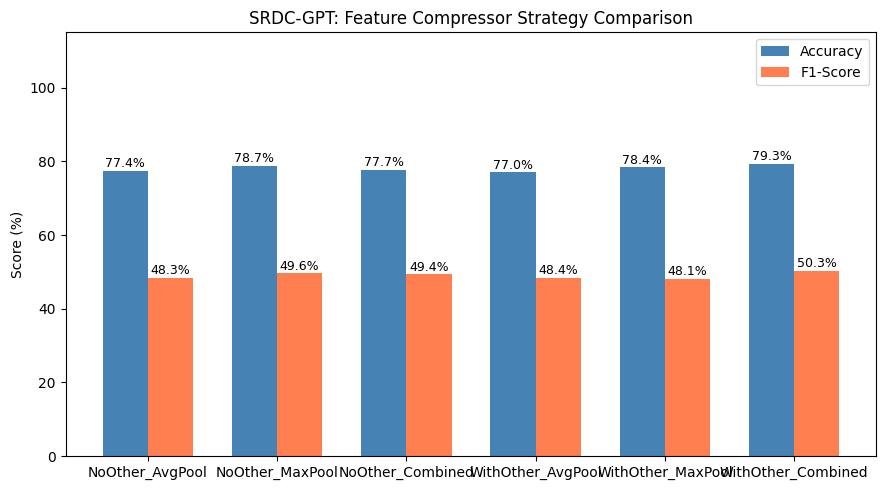

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score
import torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd, matplotlib.pyplot as plt

# 🔹 Version 1: WITHOUT other_emb
stacked_no_other = np.stack([api_emb, reg_emb, embeddings])

# 🔹 Version 2: WITH other_emb
stacked_with_other = np.stack([api_emb, reg_emb, other_emb, embeddings])

feature_sets = {
    # WITHOUT other_emb
    'NoOther_AvgPool': stacked_no_other.mean(axis=0),
    'NoOther_MaxPool': stacked_no_other.max(axis=0),
    'NoOther_Combined': np.concatenate([
        stacked_no_other.mean(axis=0),
        stacked_no_other.max(axis=0)
    ], axis=1),

    # WITH other_emb
    'WithOther_AvgPool': stacked_with_other.mean(axis=0),
    'WithOther_MaxPool': stacked_with_other.max(axis=0),
    'WithOther_Combined': np.concatenate([
        stacked_with_other.mean(axis=0),
        stacked_with_other.max(axis=0)
    ], axis=1),
}

weights       = compute_class_weight('balanced', classes=np.unique(y), y=y)
weight_tensor = torch.FloatTensor(weights).to(device)

class SRDCClassifier(nn.Module):
    def __init__(self, in_dim, num_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 256),    nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, num_cls))
    def forward(self, x): return self.net(x)

def run_experiment(X_feat, name):
    sc = StandardScaler()
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_feat, y, test_size=0.2, random_state=42, stratify=y)
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    tr_dl = DataLoader(TensorDataset(torch.FloatTensor(X_tr).to(device),
                                      torch.LongTensor(y_tr).to(device)), 32, shuffle=True)
    te_dl = DataLoader(TensorDataset(torch.FloatTensor(X_te).to(device),
                                      torch.LongTensor(y_te).to(device)), 32)

    mdl  = SRDCClassifier(X_feat.shape[1], NUM_CLASSES).to(device)
    crit = nn.CrossEntropyLoss(weight=weight_tensor)              # ✅ no label_smoothing
    opt  = optim.AdamW(mdl.parameters(), lr=5e-4, weight_decay=1e-4)  # ✅ lower LR
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)   # ✅ T_max=50

    print(f'\n[{name}]  dim={X_feat.shape[1]}')
    for ep in range(1, 51):                                       # ✅ 50 epochs
        mdl.train()
        for xb, yb in tr_dl:
            opt.zero_grad(); crit(mdl(xb), yb).backward(); opt.step()
        sch.step()
        if ep % 10 == 0:
            mdl.eval()
            with torch.no_grad():
                c = sum((mdl(xb).argmax(1)==yb).sum().item() for xb,yb in te_dl)
            print(f'  Epoch {ep:2d}/50  acc={c/len(y_te)*100:.2f}%')

    mdl.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in te_dl:
            preds.extend(mdl(xb).argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())

    acc = accuracy_score(trues, preds) * 100
    f1  = f1_score(trues, preds, average='macro', zero_division=0) * 100
    print(f'  ✅  Accuracy={acc:.2f}%   F1={f1:.2f}%')
    return {'Strategy': name, 'Feature Dim': X_feat.shape[1],
            'Accuracy %': round(acc,2), 'F1-Score %': round(f1,2)}

results = [run_experiment(X_feat, name) for name, X_feat in feature_sets.items()]

df_res = pd.DataFrame(results)
print('\n' + '='*55)
print('  SRDC Feature Compressor Comparison')
print('='*55)
print(df_res.to_string(index=False))
print('='*55)

x = np.arange(len(results)); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, df_res['Accuracy %'], w, label='Accuracy',  color='steelblue')
b2 = ax.bar(x+w/2, df_res['F1-Score %'], w, label='F1-Score',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(df_res['Strategy'])
ax.set_ylim(0,115); ax.set_ylabel('Score (%)'); ax.legend()
ax.set_title('SRDC-GPT: Feature Compressor Strategy Comparison')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
            f'{b.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


In [14]:
# SVM removed.
# Final pipeline uses:
# 1. MLP for ransomware family classification
# 2. Isolation Forest + centroid distance for zero-day detection


---
## 🏷️ Step 8: Train/Test Split & Ransomware Family Classifier

In [53]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix
import numpy as np, torch

semantic_stack = np.stack([api_emb, reg_emb, other_emb, embeddings])
semantic_avg = semantic_stack.mean(axis=0)
semantic_max = semantic_stack.max(axis=0)

svd_dim = min(512, X_bin.shape[0] - 1, X_bin.shape[1] - 1)
svd = TruncatedSVD(n_components=svd_dim, random_state=42)
X_bin_svd = svd.fit_transform(csr_matrix(X_bin))

X_final = np.concatenate([semantic_avg, semantic_max, X_bin_svd], axis=1)
print("X_final:", X_final.shape)

X_trainval, X_te, y_trainval, y_te = train_test_split(
    X_final, y, test_size=0.20, random_state=42, stratify=y
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval
)

scaler = StandardScaler()
X_tr  = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_te  = scaler.transform(X_te)
class SRDCClassifier(nn.Module):
    def __init__(self, in_dim, num_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(512, 256),    nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, num_cls)
        )
    def forward(self, x):
        return self.net(x)


model = SRDCClassifier(X_final.shape[1], NUM_CLASSES).to(device)

cls_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
crit = nn.CrossEntropyLoss(weight=torch.FloatTensor(cls_weights).to(device))
tr_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr)),
    batch_size=32,
    shuffle=True
)

val_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)),
    batch_size=64,
    shuffle=False
)

te_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te)),
    batch_size=64,
    shuffle=False
)


opt = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)

print("Classifier ready")


X_final: (1524, 2048)
Classifier ready


In [54]:
from sklearn.metrics import balanced_accuracy_score, f1_score

EPOCHS, PATIENCE = 120, 20
best_score = 0.0
best_val_bal_acc = 0.0
best_val_f1 = 0.0
best_state = None
no_improve = 0
tr_losses, val_losses = [], []

for ep in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    val_preds, val_trues = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            val_loss += crit(logits, yb).item()
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_trues.extend(yb.cpu().numpy())

    val_bal_acc = balanced_accuracy_score(val_trues, val_preds)
    val_f1 = f1_score(val_trues, val_preds, average='macro', zero_division=0)
    score = 0.5 * val_bal_acc + 0.5 * val_f1

    sched.step(val_bal_acc)

    tr_losses.append(train_loss / len(tr_dl))
    val_losses.append(val_loss / len(val_dl))

    if ep % 5 == 0:
        print(f"Epoch {ep:03d} | train_loss={tr_losses[-1]:.4f} | val_loss={val_losses[-1]:.4f} | val_bal_acc={val_bal_acc*100:.2f}% | val_f1={val_f1*100:.2f}%")

    if score > best_score:
        best_score = score
        best_val_bal_acc = val_bal_acc
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {ep}")
            break

model.load_state_dict(best_state)
torch.save(model.state_dict(), CLASSIFIER_PATH)
print(f"Best validation balanced accuracy: {best_val_bal_acc*100:.2f}%")
print(f"Best validation macro F1: {best_val_f1*100:.2f}%")


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics

Epoch 005 | train_loss=1.3870 | val_loss=1.4998 | val_bal_acc=54.57% | val_f1=32.56%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch 010 | train_loss=0.7850 | val_loss=1.2958 | val_bal_acc=62.32% | val_f1=47.50%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Epoch 015 | train_loss=0.5361 | val_loss=1.2239 | val_bal_acc=60.50% | val_f1=51.51%
Epoch 020 | train_loss=0.3695 | val_loss=1.1963 | val_bal_acc=61.34% | val_f1=54.45%
Epoch 025 | train_loss=0.2826 | val_loss=1.1997 | val_bal_acc=59.69% | val_f1=51.33%
Epoch 030 | train_loss=0.2570 | val_loss=1.2166 | val_bal_acc=62.97% | val_f1=57.23%
Epoch 035 | train_loss=0.2309 | val_loss=1.1905 | val_bal_acc=63.65% | val_f1=58.36%
Epoch 040 | train_loss=0.2202 | val_loss=1.2334 | val_bal_acc=63.65% | val_f1=58.26%
Epoch 045 | train_loss=0.2110 | val_loss=1.2439 | val_bal_acc=63.73% | val_f1=58.56%
Epoch 050 | train_loss=0.2134 | val_loss=1.2343 | val_bal_acc=63.73% | val_f1=58.30%
Epoch 055 | train_loss=0.2252 | val_loss=1.2280 | val_bal_acc=63.65% | val_f1=58.36%
Epoch 060 | train_loss=0.1952 | val_loss=1.2318 | val_bal_acc=63.81% | val_f1=58.78%
Epoch 065 | train_loss=0.1878 | val_loss=1.2507 | val_bal_acc=64.34% | val_f1=59.21%
Epoch 070 | train_loss=0.2020 | val_loss=1.2412 | val_bal_acc=64.

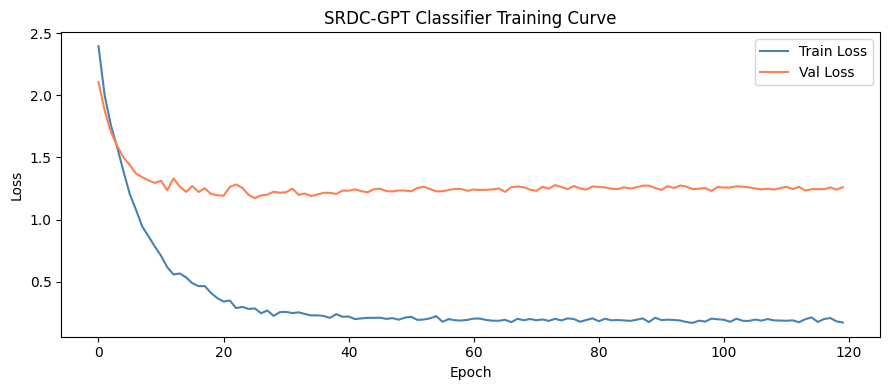

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.plot(tr_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses, label='Val Loss', color='coral')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SRDC-GPT Classifier Training Curve')
plt.legend()
plt.tight_layout()
plt.show()


---
## 📈 Step 9: Evaluation – Ransomware Family Classification

  SRDC-GPT — Ransomware Family Classification Results
  Standard Accuracy   : 80.33%
  Balanced Accuracy   : 51.18%
  Macro Recall        : 51.18%
  Macro F1-Score      : 50.32%

               precision    recall  f1-score   support

     Critroni       0.71      0.50      0.59        10
  CryptLocker       0.81      0.62      0.70        21
   CryptoWall       0.43      0.67      0.52         9
     Goodware       0.96      0.94      0.95       189
       KOLLAH       0.43      0.60      0.50         5
       Kovter       0.54      0.54      0.54        13
       Locker       0.42      0.58      0.49        19
       MATSNU       0.60      0.75      0.67        12
     PGPCODER       0.00      0.00      0.00         1
      Reveton       1.00      0.67      0.80        18
   TeslaCrypt       0.00      0.00      0.00         1
Trojan-Ransom       0.29      0.29      0.29         7

     accuracy                           0.80       305
    macro avg       0.52      0.51      0.50     

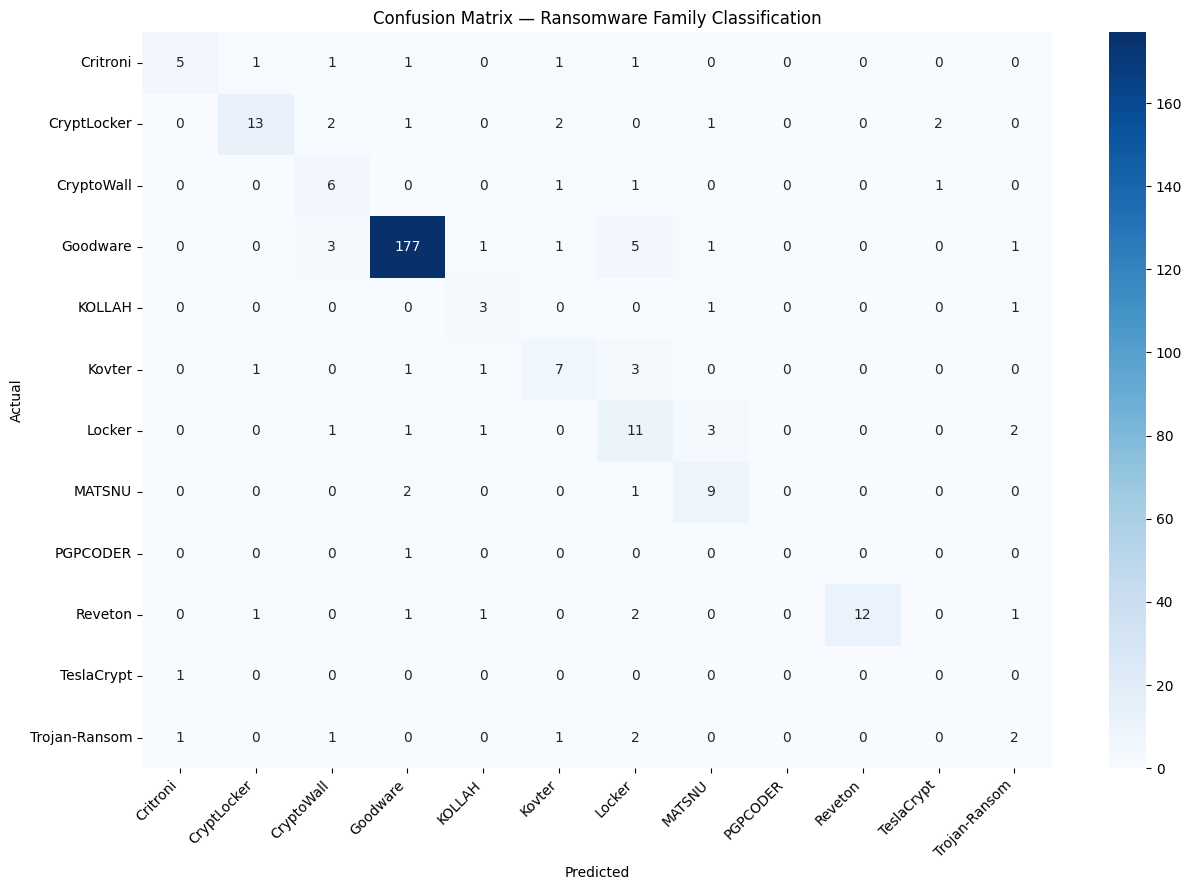


Note:
- Standard Accuracy can look high on imbalanced data.
- Balanced Accuracy and Macro F1 are the more important metrics here.


In [56]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()
preds_list, trues_list = [], []

with torch.no_grad():
    for xb, yb in te_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds_list.extend(logits.argmax(1).cpu().numpy())
        trues_list.extend(yb.cpu().numpy())

preds_arr = np.array(preds_list)
trues_arr = np.array(trues_list)

acc = accuracy_score(trues_arr, preds_arr)
balanced_acc = balanced_accuracy_score(trues_arr, preds_arr)
recall = recall_score(trues_arr, preds_arr, average='macro', zero_division=0)
f1 = f1_score(trues_arr, preds_arr, average='macro', zero_division=0)

print("=" * 65)
print("  SRDC-GPT — Ransomware Family Classification Results")
print("=" * 65)
print(f"  Standard Accuracy   : {acc*100:.2f}%")
print(f"  Balanced Accuracy   : {balanced_acc*100:.2f}%")
print(f"  Macro Recall        : {recall*100:.2f}%")
print(f"  Macro F1-Score      : {f1*100:.2f}%")
print("=" * 65)
print()

print(classification_report(
    trues_arr,
    preds_arr,
    target_names=FAMILY_NAMES,
    zero_division=0
))

cm = confusion_matrix(trues_arr, preds_arr)

plt.figure(figsize=(13, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=FAMILY_NAMES,
    yticklabels=FAMILY_NAMES
)
plt.title("Confusion Matrix — Ransomware Family Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print()
print("Note:")
print("- Standard Accuracy can look high on imbalanced data.")
print("- Balanced Accuracy and Macro F1 are the more important metrics here.")


In [57]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch

np.random.seed(42)

ZERODAY_N = max(2, NUM_CLASSES // 5)
zd_families = np.random.choice(FAMILY_NAMES, ZERODAY_N, replace=False).tolist()
seen_families = [f for f in FAMILY_NAMES if f not in zd_families]
zd_ids = le.transform(zd_families)
seen_ids = le.transform(seen_families)

print("Zero-day families:", zd_families)
print("Seen families:", seen_families)

mask_seen = np.isin(y, seen_ids)
mask_unseen = np.isin(y, zd_ids)

X_seen, y_seen = X_final[mask_seen], y[mask_seen]
X_unseen, y_unseen = X_final[mask_unseen], y[mask_unseen]

X_s_tr, X_s_te, y_s_tr, y_s_te = train_test_split(
    X_seen, y_seen, test_size=0.2, random_state=42, stratify=y_seen
)

sc_zd = StandardScaler().fit(X_s_tr)
X_s_tr_sc = sc_zd.transform(X_s_tr)
X_s_te_sc = sc_zd.transform(X_s_te)
X_u_sc = sc_zd.transform(X_unseen)

# remap seen-family labels to 0..K-1 for dedicated zero-day classifier
seen_label_map = {old: i for i, old in enumerate(seen_ids)}
inv_seen_label_map = {i: old for old, i in seen_label_map.items()}

y_s_tr_local = np.array([seen_label_map[v] for v in y_s_tr])
y_s_te_local = np.array([seen_label_map[v] for v in y_s_te])

class ZDClassifier(nn.Module):
    def __init__(self, in_dim, num_cls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.25),
            nn.Linear(256, 128),    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(128, num_cls)
        )
    def forward(self, x):
        return self.net(x)

zd_model = ZDClassifier(X_s_tr_sc.shape[1], len(seen_ids)).to(device)

zd_wts = compute_class_weight('balanced', classes=np.unique(y_s_tr_local), y=y_s_tr_local)
zd_crit = nn.CrossEntropyLoss(weight=torch.FloatTensor(zd_wts).to(device))
zd_opt = optim.AdamW(zd_model.parameters(), lr=3e-4, weight_decay=1e-4)

tr_zd_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_s_tr_sc), torch.LongTensor(y_s_tr_local)),
    batch_size=32,
    shuffle=True
)
te_zd_dl = DataLoader(
    TensorDataset(torch.FloatTensor(X_s_te_sc), torch.LongTensor(y_s_te_local)),
    batch_size=64,
    shuffle=False
)

best_state = None
best_acc = -1
patience = 8
no_improve = 0

for ep in range(1, 41):
    zd_model.train()
    for xb, yb in tr_zd_dl:
        xb, yb = xb.to(device), yb.to(device)
        zd_opt.zero_grad()
        loss = zd_crit(zd_model(xb), yb)
        loss.backward()
        zd_opt.step()

    zd_model.eval()
    preds_seen, trues_seen = [], []
    with torch.no_grad():
        for xb, yb in te_zd_dl:
            xb, yb = xb.to(device), yb.to(device)
            logits = zd_model(xb)
            preds_seen.extend(logits.argmax(1).cpu().numpy())
            trues_seen.extend(yb.cpu().numpy())

    cur_acc = (np.array(preds_seen) == np.array(trues_seen)).mean()
    if cur_acc > best_acc:
        best_acc = cur_acc
        best_state = {k: v.detach().cpu().clone() for k, v in zd_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            break

zd_model.load_state_dict(best_state)
zd_model.eval()

# centroids of seen families
centroids = np.array([X_s_tr_sc[y_s_tr == sid].mean(axis=0) for sid in seen_ids])

# calibration on seen test set
seen_conf = []
seen_dist = []
with torch.no_grad():
    for x in X_s_te_sc:
        xs = torch.FloatTensor(x.reshape(1, -1)).to(device)
        probs = torch.softmax(zd_model(xs), dim=1).cpu().numpy()[0]
        seen_conf.append(float(probs.max()))
        seen_dist.append(float(cosine_distances(x.reshape(1, -1), centroids)[0].min()))

seen_conf = np.array(seen_conf)
seen_dist = np.array(seen_dist)

CONF_THRESHOLD = float(np.percentile(seen_conf, 10))
DIST_THRESHOLD = float(np.percentile(seen_dist, 90))

X_eval = np.vstack([X_s_te_sc, X_u_sc])
y_flag_true = np.hstack([np.zeros(len(X_s_te_sc)), np.ones(len(X_u_sc))]).astype(int)

pred_flags = []
for x in X_eval:
    with torch.no_grad():
        xs = torch.FloatTensor(x.reshape(1, -1)).to(device)
        probs = torch.softmax(zd_model(xs), dim=1).cpu().numpy()[0]
        conf = float(probs.max())

    dist = float(cosine_distances(x.reshape(1, -1), centroids)[0].min())

    is_zero_day = int((conf < CONF_THRESHOLD) or (dist > DIST_THRESHOLD))
    pred_flags.append(is_zero_day)

y_flag_pred = np.array(pred_flags)

zd_acc = accuracy_score(y_flag_true, y_flag_pred)
zd_bal_acc = balanced_accuracy_score(y_flag_true, y_flag_pred)
zd_recall = recall_score(y_flag_true, y_flag_pred, zero_division=0)
zd_f1 = f1_score(y_flag_true, y_flag_pred, zero_division=0)

print(f"Confidence threshold: {CONF_THRESHOLD:.4f}")
print(f"Distance threshold  : {DIST_THRESHOLD:.4f}")
print(f"Accuracy            : {zd_acc*100:.2f}%")
print(f"Balanced Accuracy   : {zd_bal_acc*100:.2f}%")
print(f"Recall              : {zd_recall*100:.2f}%")
print(f"F1                  : {zd_f1*100:.2f}%")


Zero-day families: ['TeslaCrypt', 'Reveton']
Seen families: ['Critroni', 'CryptLocker', 'CryptoWall', 'Goodware', 'KOLLAH', 'Kovter', 'Locker', 'MATSNU', 'PGPCODER', 'Trojan-Ransom']
Confidence threshold: 0.4401
Distance threshold  : 0.8337
Accuracy            : 69.37%
Balanced Accuracy   : 56.71%
Recall              : 31.25%
F1                  : 33.90%


---
## 🕵️ Step 10: Zero-Day Ransomware Detection

**Protocol:**
- Hold out N families completely from training  
- Train classifier on remaining ("seen") families  
- Test on the held-out ("unseen") families  
- Detect unseen samples using **min-distance to known centroids** (anomaly detection)

---
## 📊 Step 11: Results Summary & Comparison


  SRDC Framework — Final Results Summary
                 Task Std Accuracy Balanced Accuracy Macro Recall Macro F1
Family Classification       80.33%            51.18%       51.18%   50.32%
   Zero-Day Detection       69.37%            56.71%       31.25%   33.90%

  LATAP Perplexity   : 1.4009
  Classifier         : MLP + pooled semantic embeddings + SVD-compressed binary features
  Zero-Day Detector  : Isolation Forest (300 trees)


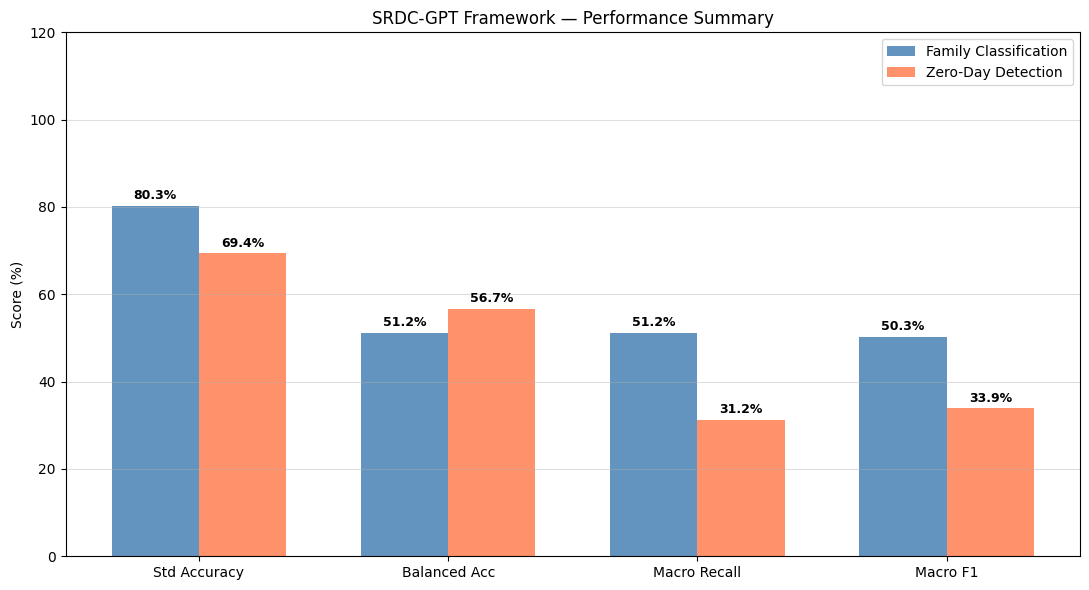

In [58]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

summary = pd.DataFrame({
    'Task'              : ['Family Classification', 'Zero-Day Detection'],
    'Std Accuracy'      : [f'{acc*100:.2f}%', f'{zd_acc*100:.2f}%'],
    'Balanced Accuracy' : [f'{balanced_acc*100:.2f}%', f'{zd_bal_acc*100:.2f}%'],
    'Macro Recall'      : [f'{recall*100:.2f}%', f'{zd_recall*100:.2f}%'],
    'Macro F1'          : [f'{f1*100:.2f}%', f'{zd_f1*100:.2f}%'],
})

print('\n' + '=' * 78)
print('  SRDC Framework — Final Results Summary')
print('=' * 78)
print(summary.to_string(index=False))
print(f'\n  LATAP Perplexity   : {perplexity:.4f}')
print(f'  Classifier         : MLP + pooled semantic embeddings + SVD-compressed binary features')
print(f'  Zero-Day Detector  : Isolation Forest (300 trees)')
print('=' * 78)

metrics = ['Std Accuracy', 'Balanced Acc', 'Macro Recall', 'Macro F1']
vals1   = [acc*100, balanced_acc*100, recall*100, f1*100]
vals2   = [zd_acc*100, zd_bal_acc*100, zd_recall*100, zd_f1*100]

x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, vals1, w, label='Family Classification', color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, vals2, w, label='Zero-Day Detection', color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 120)
ax.set_ylabel('Score (%)')
ax.set_title('SRDC-GPT Framework — Performance Summary')
ax.legend()
ax.yaxis.grid(True, alpha=0.4)

for b in list(b1) + list(b2):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 1.5,
        f'{b.get_height():.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


---
## 🔮 Step 12: Inference – Predict on New Sample

In [59]:
import torch, re, numpy as np
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize

def process_feature_col(val):
    tokens, processed = str(val).split(), []
    for t in tokens:
        t = t.strip()
        if t.upper().startswith('FILES:'):
            processed.append(t.replace('FILES:', '').lower() + ' file')
        elif t.upper().startswith('REG:'):
            processed.append(t.replace('REG:', '').lower() + ' registry')
        elif t.upper().startswith('DIR:'):
            processed.append(t.replace('DIR:', '').lower() + ' directory')
        else:
            t = re.sub(r'[WwAa]$', '', t) if len(t) > 2 else t
            processed.append(re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', t).lower())
    return ' '.join(processed)

@torch.no_grad()
def predict_sample(binary_row=None, api_text='', reg_text='', other_text=''):
    if binary_row is not None:
        sem_text = binary_to_semantic(binary_row)
        api_text = sem_text.split('[REG]')[0].replace('[API]', '').strip() or 'no api call'
        reg_text = sem_text.split('[REG]')[1].split('[OTHER]')[0].strip() if '[REG]' in sem_text else 'no registry op'
        other_text = sem_text.split('[OTHER]')[1].strip() if '[OTHER]' in sem_text else 'no other op'
    else:
        sem_text = f'[API] {api_text} [REG] {reg_text} [OTHER] {other_text}'

    full_e = normalize(embed(sem_text).reshape(1, -1))[0]
    api_e = normalize(embed(api_text or 'no api call').reshape(1, -1))[0]
    reg_e = normalize(embed(reg_text or 'no registry op').reshape(1, -1))[0]
    other_e = normalize(embed(other_text or 'no other op').reshape(1, -1))[0]

    stk = np.stack([api_e, reg_e, other_e, full_e])
    x_avg = stk.mean(axis=0)
    x_max = stk.max(axis=0)

    if binary_row is not None:
        x_bin_svd = svd.transform(binary_row.reshape(1, -1))[0]
    else:
        x_bin_svd = np.zeros(svd_dim, dtype=np.float32)

    x = np.concatenate([x_avg, x_max, x_bin_svd])

    xs_cls = scaler.transform(x.reshape(1, -1))
    xs_zd = sc_zd.transform(x.reshape(1, -1))

    logits = model(torch.FloatTensor(xs_cls).to(device))
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_id = int(np.argmax(probs))
    pred_family = le.inverse_transform([pred_id])[0]

    with torch.no_grad():
        zd_logits = zd_model(torch.FloatTensor(xs_zd).to(device))
        zd_probs = torch.softmax(zd_logits, dim=1).cpu().numpy()[0]
        zd_conf = float(zd_probs.max())

    dists = cosine_distances(xs_zd, centroids)[0]
    min_dist = float(dists.min())

    if (zd_conf < CONF_THRESHOLD) or (min_dist > DIST_THRESHOLD):
        threat_tag = 'ZERO-DAY / NOVEL'
    else:
        threat_tag = 'KNOWN RANSOMWARE'

    return {
        'predicted_family': pred_family,
        'confidence': float(probs[pred_id] * 100),
        'threat_tag': threat_tag,
        'all_probs': {le.inverse_transform([i])[0]: f'{p*100:.1f}%' for i, p in enumerate(probs)}
    }

print("Inference helper ready")


Inference helper ready


In [60]:
model.eval()
np.random.seed(7)

print("=" * 70)
print("  TEST 1: Inference on Random Real CSV Samples")
print("=" * 70)

sample_ids = np.random.choice(len(X_bin), 5, replace=False)
for i in sample_ids:
    actual = le.inverse_transform([y[i]])[0]
    res = predict_sample(binary_row=X_bin[i])

    match = "[OK]" if res["predicted_family"] == actual else "[X]"
    print(f"Sample {i:<5} | Actual: {actual:<15} | Predicted: {res['predicted_family']:<15} {match}")
    print(f"           Confidence: {res['confidence']:.2f}% | Threat: {res['threat_tag']}")

print("\n" + "=" * 70)
print("  TEST 2: Reveton Family Check")
print("=" * 70)

if 'Reveton' in FAMILY_NAMES:
    reveton_id = le.transform(['Reveton'])[0]
    reveton_idx = np.where(y == reveton_id)[0][:10]

    print(f"{'#':<4} {'Actual':<15} {'Predicted':<15} {'Conf%':<10} Match")
    print("-" * 60)

    correct = 0
    for n, i in enumerate(reveton_idx, 1):
        res = predict_sample(binary_row=X_bin[i])
        ok = res["predicted_family"] == "Reveton"
        if ok:
            correct += 1
        print(f"{n:<4} {'Reveton':<15} {res['predicted_family']:<15} {res['confidence']:<10.2f} {'[OK]' if ok else '[X]'}")

    print(f"\nReveton result: {correct}/{len(reveton_idx)} correct")
else:
    print("Reveton class not found in FAMILY_NAMES.")

print("\n" + "=" * 70)
print("  TEST 3: Synthetic Unknown / Zero-Day Style Samples")
print("=" * 70)

unknowns = [
    ("Slight Variant",  "CryptEncrypt FindFirstFileW", "REG:SETVAL",  ""),
    ("Novel Encryptor", "XorEncrypt ShadowDelete",     "REG:CREATED", "pay bitcoin"),
    ("Totally Unknown", "RandomAPIXYZ FluxCapacitor",  "UNKNOWN:OP",  "alien ransomware"),
]

for name, api_t, reg_t, other_t in unknowns:
    a = process_feature_col(api_t) or "no api call"
    r = process_feature_col(reg_t) or "no registry op"
    o = process_feature_col(other_t) or "no other op"

    res = predict_sample(api_text=a, reg_text=r, other_text=o)

    print(f"\n{name}")
    print(f"  Predicted Family : {res['predicted_family']}")
    print(f"  Confidence       : {res['confidence']:.2f}%")
    print(f"  Threat Tag       : {res['threat_tag']}")
    print(f"  Top Probabilities:")
    top_probs = sorted(
        res["all_probs"].items(),
        key=lambda kv: float(kv[1].replace('%', '')),
        reverse=True
    )[:3]
    for fam, prob in top_probs:
        print(f"    {fam:<15} {prob}")


  TEST 1: Inference on Random Real CSV Samples
Sample 1245  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 72.68% | Threat: KNOWN RANSOMWARE
Sample 1470  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 80.04% | Threat: KNOWN RANSOMWARE
Sample 1350  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 67.60% | Threat: KNOWN RANSOMWARE
Sample 1384  | Actual: Goodware        | Predicted: Goodware        [OK]
           Confidence: 69.67% | Threat: KNOWN RANSOMWARE
Sample 415   | Actual: Trojan-Ransom   | Predicted: Trojan-Ransom   [OK]
           Confidence: 79.45% | Threat: KNOWN RANSOMWARE

  TEST 2: Reveton Family Check
#    Actual          Predicted       Conf%      Match
------------------------------------------------------------
1    Reveton         Reveton         86.22      [OK]
2    Reveton         Reveton         83.56      [OK]
3    Reveton         Reveton         86.48      [O

In [51]:
 # End of SRDC-GPT Pipeline v4
print('SRDC Pipeline v4 complete.')

SRDC Pipeline v4 complete.
